# Bathymetry and forcing 

This is constant over all the experiments so, for now specific reason, I get the sea floor from the $z^{*}$ experiment.

In [2]:
tub_output_dir = "/g/data/e14/jb2381/anu-tub/outputs"
if pwd() != tub_output_dir 
    cd(tub_output_dir)
end
include("plotting.jl")

  Activating project at `/g/data/e14/jb2381/anu-tub/outputs`
[ Info: Plotting and analysis environment setup!
┌ Info: Experiments in the catalogue are:
│        - zstar-PPMH3
│        - hycom-PPMH3
│        Available data is:
│           - daily
│           - monthly
│           - monthlyz
│           - monthlyrho2
│           - static
└           - vertical coordinate


## Domain info from `ocean_static.nc`

In [4]:
# Extract output paths specific to this experiment and change to its directory
expt = catalogue["zstar-PPMH3"]

static = expt["static"]
vc = expt["vc"]

crs = get_geo_coords(static, vc)
nothing

## Forcing files

Momentum forcing: constant in time, meridionally varying zonal wind
Thermal forcing: constant in time, meridionally varying sst

In [3]:
mf_file = "../input/anu-tub/forcing.nc"
tf_file = "../input/anu-tub/sst.nc"

ds = NCDataset(mf_file)
taux = ds["tau_x"][1, :]
close(ds)

ds = NCDataset(tf_file)
sstf = ds["SST"][1, :]
close(ds)

closed Dataset

## Figure

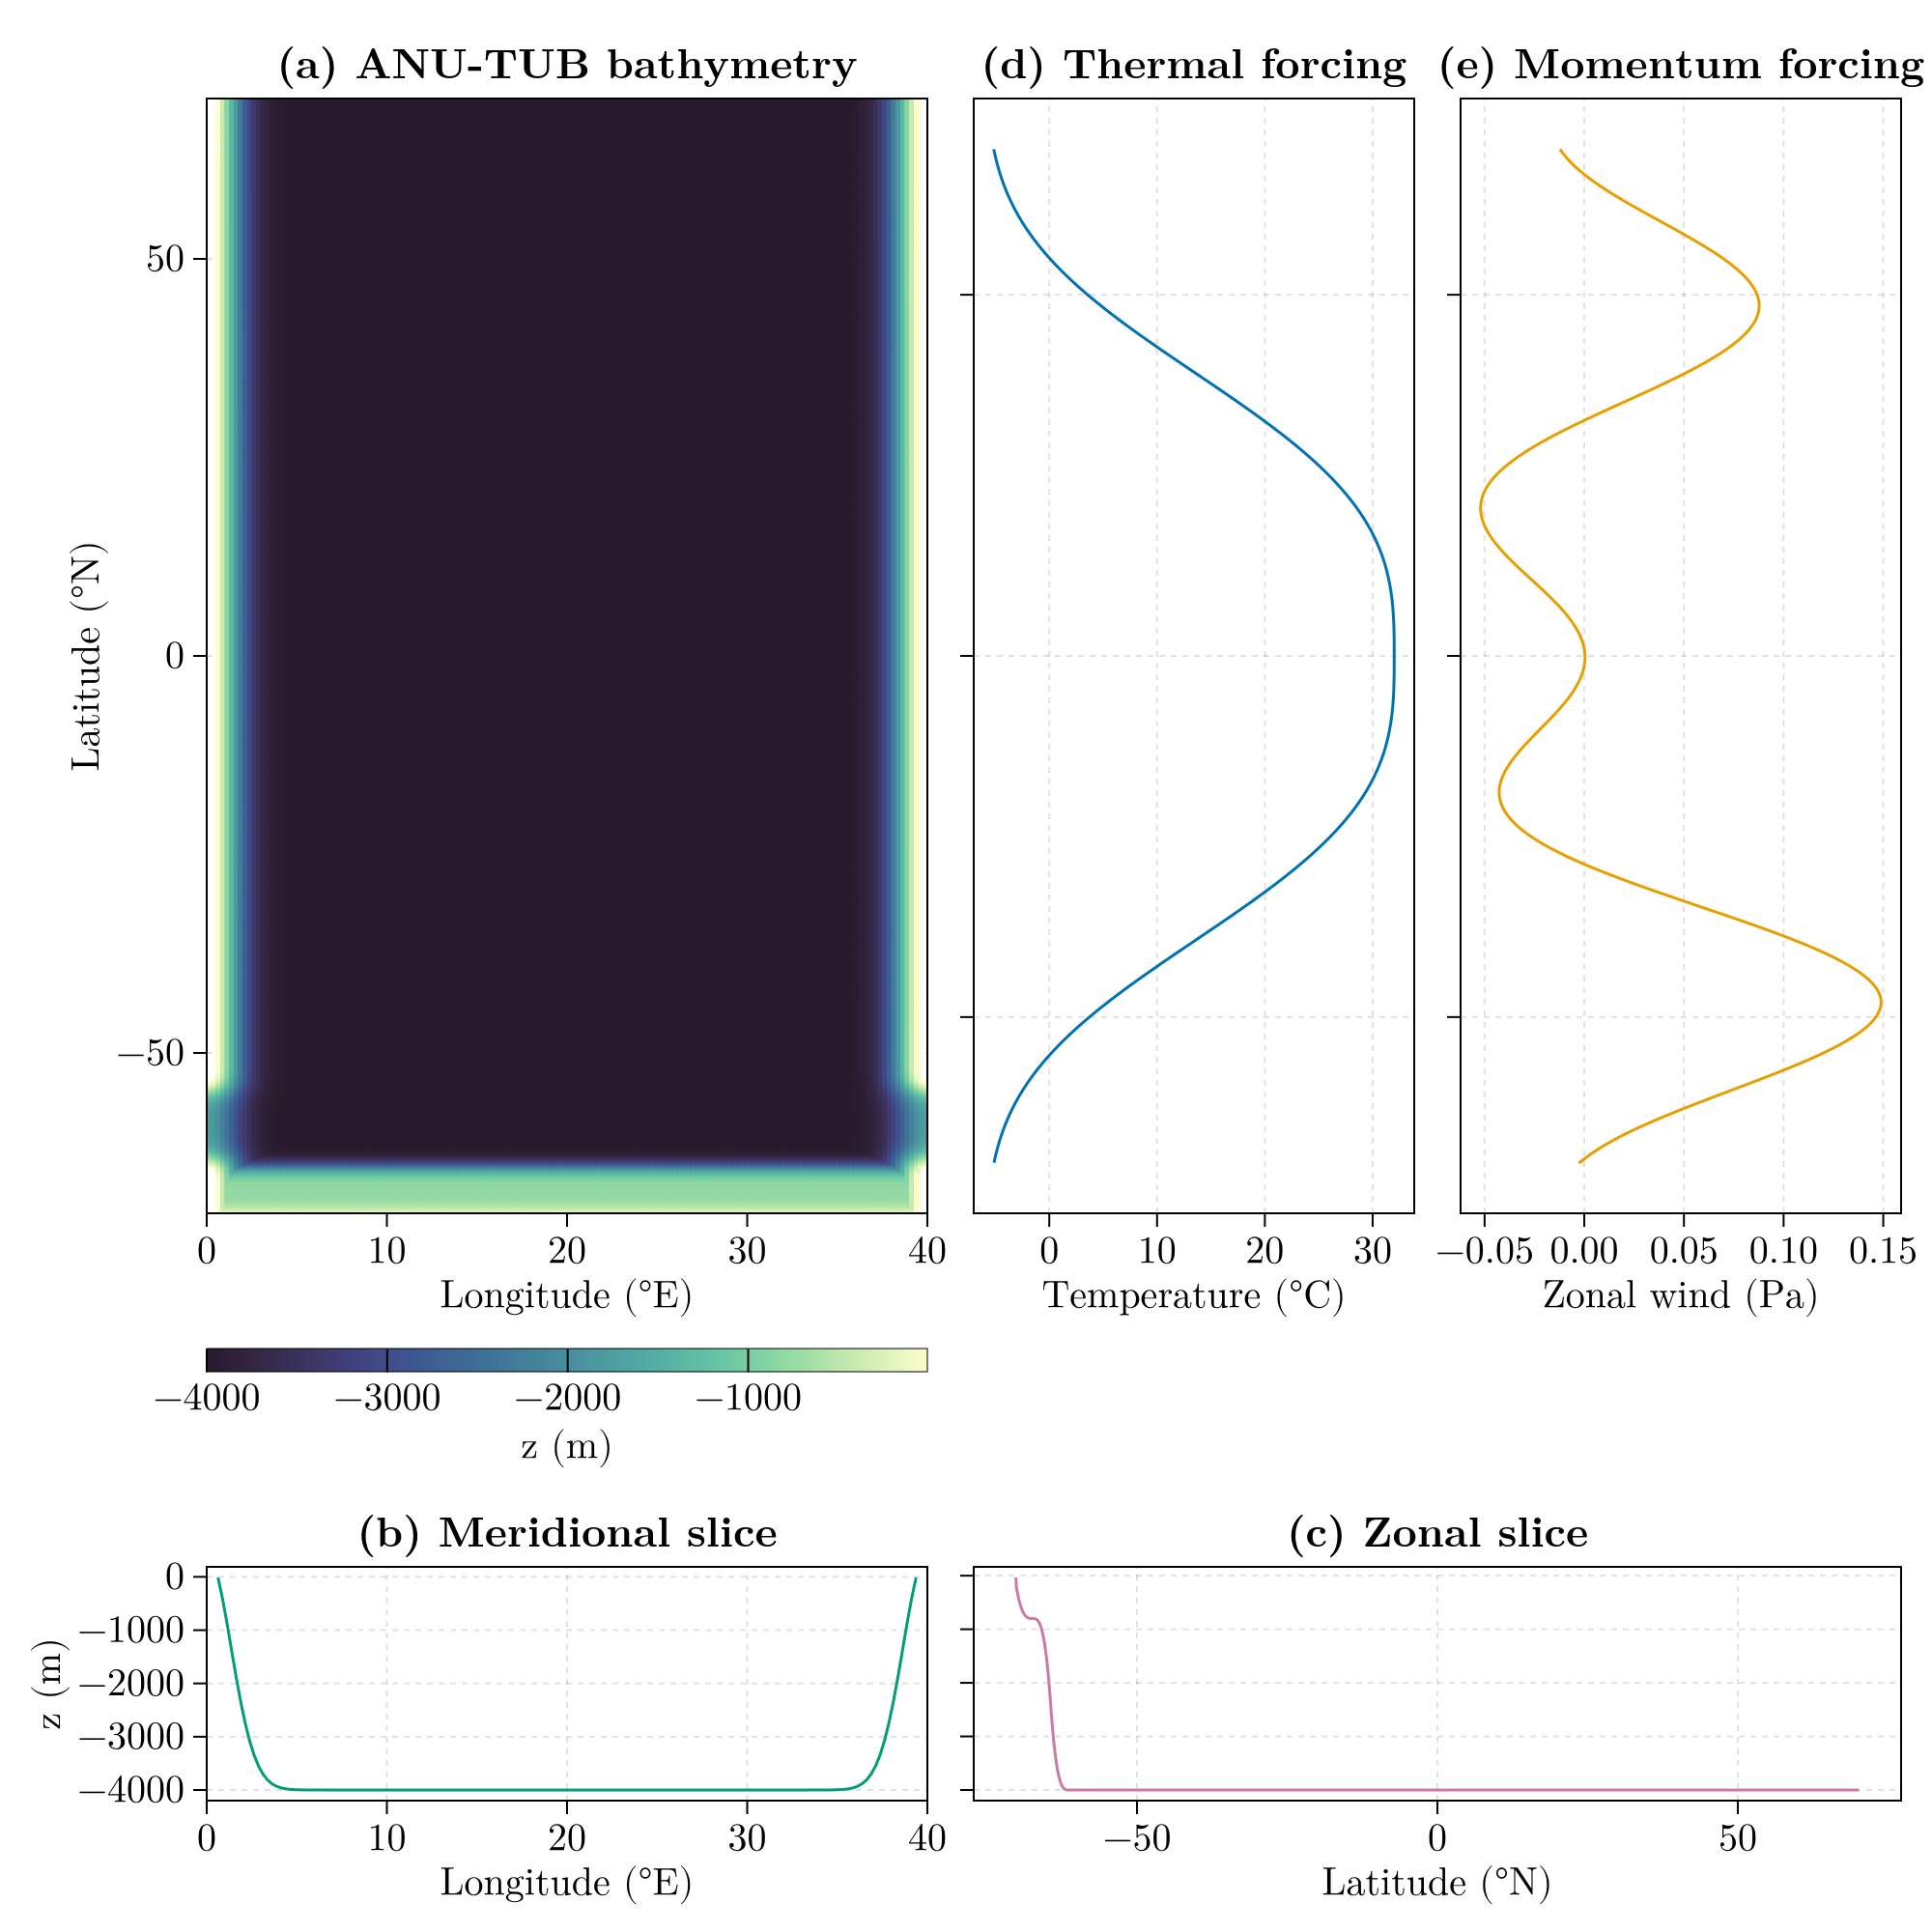

In [6]:
lon_select = findfirst(crs.lonh .≥ 20)
lat_select = findfirst(crs.lath .≥ 0)

fig = Figure(size = (1000, 1000))

## Forcings
# temperature
ax_tf = Axis(fig[1, 2], xlabel = "Temperature (°C)", title = "(d) Thermal forcing")
hideydecorations!(ax_tf, grid = false, ticks = false)
lines!(ax_tf, sstf, crs.lath, color = Makie.wong_colors()[1])

# momentum
ax_mf = Axis(fig[1, 3], xlabel = "Zonal wind (Pa)", title = "(e) Momentum forcing")
hideydecorations!(ax_mf, grid = false, ticks = false)
lines!(ax_mf, taux, crs.lath, color = Makie.wong_colors()[2])

## Bathymetry
# whole domain
ax_bt = Axis(fig[1, 1], xlabel = "Longitude (°E)", ylabel = "Latitude (°N)", title = "(a) ANU-TUB bathymetry")
hm = heatmap!(ax_bt, crs.lonh, crs.lath, crs.sf, colormap = Reverse(:deep))
xlims!(ax_bt, 0, 40)
Colorbar(fig[2, 1], hm ,label = "z (m)", vertical = false, flipaxis = false)

# meridional slice
ax_m = Axis(fig[3, 1], xlabel = "Longitude (°E)", ylabel = "z (m)", title = "(b) Meridional slice")
xlims!(ax_m, 0, 40)
lines!(ax_m, crs.lonh, crs.sf[:, lat_select], color = Makie.wong_colors()[3])

# zonal slice
ax_z = Axis(fig[3, 2:3], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "(c) Zonal slice")
hideydecorations!(ax_z, grid = false, ticks = false)
lines!(ax_z, crs.lath, crs.sf[lon_select, :], color = Makie.wong_colors()[4])

linkxaxes!(ax_bt, ax_m)

colsize!(fig.layout, 1, Relative(0.9/2))
rowsize!(fig.layout, 1, Relative(3.25/4))

fig

In [ ]:
save("tub_forcing_bathy.png", fig)